# Homework 5 Solution

This notebook provides one example solution for the PCA assignment.


**Example choice:** This solution uses **Germany** for **2005-2020**.

The idea is to build a composite development index from indicators that reflect:
- economic development;
- social progress;
- environmental sustainability.

You can replace the country later if you want to build another valid solution.


In [1]:
from pathlib import Path

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "README.md").exists() and (candidate / "data").exists():
            return candidate
    return current

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
ASSETS_DIR = PROJECT_ROOT / "assets"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT


PosixPath('/Users/hanyu/Documents/GitHub/big-data-analysis-2025')

In [2]:
MODULE_OUTPUT_DIR = OUTPUT_DIR / "homework_05"
MODULE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODULE_OUTPUT_DIR


PosixPath('/Users/hanyu/Documents/GitHub/big-data-analysis-2025/outputs/homework_05')

**Optional setup**


In [3]:
%pip install -q factor_analyzer scikit-learn seaborn openpyxl


Note: you may need to restart the kernel to use updated packages.


## Task 1. Read the assignment template and WDI data


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

assignment_df = pd.read_csv(DATA_DIR / "wdi" / "country_assignment_template.csv")
wdi_df = pd.read_csv(DATA_DIR / "wdi" / "WDI_course_subset.csv")

assignment_df.head()


,student_id,assigned_country,notes
0,2026001,United States,example only
1,2026002,Japan,example only


In [5]:
country_name = "Germany"
start_year = 2005
end_year = 2020

country_raw = wdi_df[wdi_df["Country Name"] == country_name]

panel_data = country_raw.drop(columns="Indicator Code").melt(
    id_vars=["Country Name", "Country Code", "Indicator Name"],
    var_name="Year",
).pivot_table(
    values="value",
    index=["Country Name", "Country Code", "Year"],
    columns="Indicator Name",
).reset_index().rename_axis("", axis=1)

panel_data["Year"] = panel_data["Year"].astype(str).astype(int)
panel_data = panel_data.query("@start_year <= Year <= @end_year").copy()

panel_data.head()


,Country Name,Country Code,Year,Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+),...,"Vulnerable employment, female (% of female employment) (modeled ILO estimate)","Vulnerable employment, male (% of male employment) (modeled ILO estimate)","Vulnerable employment, total (% of total employment) (modeled ILO estimate)","Wage and salaried workers, female (% of female employment) (modeled ILO estimate)","Wage and salaried workers, male (% of male employment) (modeled ILO estimate)","Wage and salaried workers, total (% of total employment) (modeled ILO estimate)","Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)",Wholesale price index (2010 = 100),Women Business and the Law Index Score (scale 1-100),Women's share of population ages 15+ living with HIV (%)
45,Germany,DEU,2005,100.0,100.0,100.0,100.0,100.0,100.0,NaN,...,6.720337,7.502617,7.149301,90.888857,85.150999,87.742498,73.615406,NaN,79.375,17.917397
46,Germany,DEU,2006,100.0,100.0,100.0,100.0,100.0,100.0,NaN,...,6.640368,7.605591,7.167347,90.859369,84.860399,87.584119,77.618499,NaN,81.875,17.718648
47,Germany,DEU,2007,100.0,100.0,100.0,100.0,100.0,100.0,NaN,...,6.389698,7.203105,6.832036,91.187079,85.601599,88.149644,98.375111,NaN,93.750,17.538951
48,Germany,DEU,2008,100.0,100.0,100.0,100.0,100.0,100.0,NaN,...,5.961256,6.950270,6.502079,91.610568,85.989380,88.536731,82.378164,NaN,93.750,17.388836
49,Germany,DEU,2009,100.0,100.0,100.0,100.0,100.0,100.0,NaN,...,5.753339,7.097685,6.477875,91.769132,85.646049,88.469090,76.205031,NaN,96.875,17.265103


## Task 2. Select indicators based on economic logic

This solution uses six indicators:

1. **GDP per capita (constant 2015 US$)**: captures income and productive capacity.
2. **Life expectancy at birth**: captures health and social welfare.
3. **Government expenditure on education (% of GDP)**: captures public investment in human capital.
4. **Renewable energy consumption (% of total final energy consumption)**: captures energy transition and sustainability.
5. **PM2.5 air pollution**: captures environmental quality; lower pollution is better.
6. **Infant mortality rate**: captures basic public health; lower mortality is better.

For PCA, it is helpful if all variables move in the same welfare direction, so the two negative indicators will be reversed before standardization.


In [6]:
indicator_info = pd.DataFrame(
    {
        "dimension": [
            "Economic development",
            "Social progress",
            "Social progress",
            "Environmental sustainability",
            "Environmental sustainability",
            "Social progress",
        ],
        "direction": ["positive", "positive", "positive", "positive", "negative", "negative"],
    },
    index=[
        "GDP per capita (constant 2015 US$)",
        "Life expectancy at birth, total (years)",
        "Government expenditure on education, total (% of GDP)",
        "Renewable energy consumption (% of total final energy consumption)",
        "PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",
        "Mortality rate, infant (per 1,000 live births)",
    ],
)

selected_data = panel_data[["Country Name", "Country Code", "Year", *indicator_info.index]].copy()
selected_data[indicator_info.index] = (
    selected_data[indicator_info.index]
    .infer_objects(copy=False)
    .interpolate(method="linear", limit_direction="both")
)

negative_indicators = indicator_info.query("direction == 'negative'").index.tolist()
selected_data[negative_indicators] = -selected_data[negative_indicators]

selected_data.to_csv(MODULE_OUTPUT_DIR / "Homework5_selected_indicators.csv", index=False)
selected_data.head()


,Country Name,Country Code,Year,GDP per capita (constant 2015 US$),"Life expectancy at birth, total (years)","Government expenditure on education, total (% of GDP)",Renewable energy consumption (% of total final energy consumption),"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)","Mortality rate, infant (per 1,000 live births)"
45,Germany,DEU,2005,36006.857813,78.931707,4.107311,7.3,-16.554298,-3.9
46,Germany,DEU,2006,37437.391878,79.131707,4.025274,8.6,-16.467334,-3.8
47,Germany,DEU,2007,38570.914637,79.534146,3.922466,10.5,-16.417884,-3.7
48,Germany,DEU,2008,38996.143411,79.736585,4.549240,10.2,-16.376655,-3.6
49,Germany,DEU,2009,36927.192029,79.836585,4.340054,10.7,-16.314355,-3.5


In [7]:
missing_summary = selected_data[indicator_info.index].isna().sum().sort_values()
missing_summary



GDP per capita (constant 2015 US$)                                        0
Life expectancy at birth, total (years)                                   0
Government expenditure on education, total (% of GDP)                     0
Renewable energy consumption (% of total final energy consumption)        0
PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)    0
Mortality rate, infant (per 1,000 live births)                            0
dtype: int64

## Task 3. Standardize the variables and run PCA


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

X = selected_data[indicator_info.index].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmo_all, kmo_model = calculate_kmo(X_scaled)
chi_square_value, p_value = calculate_bartlett_sphericity(X_scaled)

pca = PCA()
component_scores = pca.fit_transform(X_scaled)

pca_summary = pd.DataFrame(
    {
        "Component": [f"PC{i+1}" for i in range(len(indicator_info))],
        "Eigenvalue": pca.explained_variance_,
        "Variance contribution rate": pca.explained_variance_ratio_,
        "Cumulative variance contribution rate": pca.explained_variance_ratio_.cumsum(),
    }
)

loadings = pd.DataFrame(
    pca.components_.T,
    index=indicator_info.index,
    columns=[f"PC{i+1}" for i in range(len(indicator_info))],
)

kmo_table = pd.DataFrame({
    "Statistic": ["KMO", "Bartlett chi-square", "Bartlett p-value"],
    "Value": [kmo_model, chi_square_value, p_value],
})

pca_summary.to_csv(MODULE_OUTPUT_DIR / "Homework5_pca_summary.csv", index=False)
loadings.to_csv(MODULE_OUTPUT_DIR / "Homework5_pca_loadings.csv")
kmo_table.to_csv(MODULE_OUTPUT_DIR / "Homework5_kmo_bartlett.csv", index=False)

kmo_table


,Statistic,Value
0,KMO,8.269127e-01
1,Bartlett chi-square,1.461257e+02
2,Bartlett p-value,1.415616e-23


In [9]:
pca_summary


,Component,Eigenvalue,Variance contribution rate,Cumulative variance contribution rate
0,PC1,5.808662,0.907603,0.907603
1,PC2,0.350761,0.054806,0.962410
2,PC3,0.112335,0.017552,0.979962
3,PC4,0.066475,0.010387,0.990349
4,PC5,0.049991,0.007811,0.998160
5,PC6,0.011776,0.001840,1.000000


In [10]:
loadings.iloc[:, :3].round(4)


,PC1,PC2,PC3
GDP per capita (constant 2015 US$),0.4066,-0.3966,-0.4228
"Life expectancy at birth, total (years)",0.4192,-0.0694,-0.3970
"Government expenditure on education, total (% of GDP)",0.3744,0.8279,0.1266
Renewable energy consumption (% of total final energy consumption),0.4217,0.0002,0.2250
"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",0.4041,-0.3818,0.7347
"Mortality rate, infant (per 1,000 live births)",0.4215,0.0819,-0.2392


### Retain the first two principal components

In this example, the cumulative variance contribution rate of the first two principal components is already above 85%, so keeping **PC1** and **PC2** is enough for a compact composite index.


In [11]:
n_components = int(np.argmax(pca_summary["Cumulative variance contribution rate"] >= 0.85) + 1)
weights = pca.explained_variance_ratio_[:n_components]

development_index = component_scores[:, :n_components] @ weights

# PCA signs are arbitrary, so orient the index so that it is positively related to GDP per capita.
if np.corrcoef(development_index, selected_data["GDP per capita (constant 2015 US$)"])[0, 1] < 0:
    development_index = -development_index
    component_scores[:, :n_components] = -component_scores[:, :n_components]
    loadings.iloc[:, :n_components] = -loadings.iloc[:, :n_components]

result_df = selected_data[["Country Name", "Country Code", "Year"]].copy()
for i in range(n_components):
    result_df[f"PC{i+1}"] = component_scores[:, i]
result_df["development_index"] = development_index
result_df["development_rank"] = result_df["development_index"].rank(ascending=False, method="dense")

result_df.to_csv(MODULE_OUTPUT_DIR / "Homework5_development_index.csv", index=False)
result_df


,Country Name,Country Code,Year,PC1,development_index,development_rank
45,Germany,DEU,2005,-4.309331,-3.911164,16.0
46,Germany,DEU,2006,-3.643672,-3.307010,15.0
47,Germany,DEU,2007,-2.846822,-2.583785,14.0
48,Germany,DEU,2008,-1.971472,-1.789315,12.0
49,Germany,DEU,2009,-2.168882,-1.968485,13.0
50,Germany,DEU,2010,-1.019025,-0.924870,11.0
51,Germany,DEU,2011,-0.092102,-0.083592,10.0
52,Germany,DEU,2012,0.419757,0.380973,9.0
53,Germany,DEU,2013,0.630424,0.572175,8.0
54,Germany,DEU,2014,1.392944,1.264241,6.0


## Task 4. Export figures for the written report

A written report can use these figures to explain the PCA process and the time trend of the composite development index.


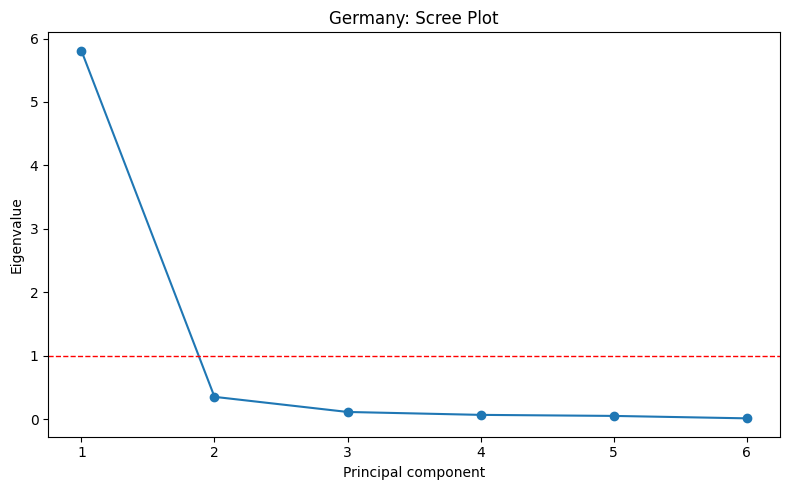

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca_summary) + 1), pca_summary["Eigenvalue"], marker="o")
plt.axhline(y=1, color="red", linestyle="--", linewidth=1)
plt.xlabel("Principal component")
plt.ylabel("Eigenvalue")
plt.title(f"{country_name}: Scree Plot")
plt.tight_layout()
plt.savefig(MODULE_OUTPUT_DIR / "Homework5_scree_plot.png", bbox_inches="tight")
plt.show()


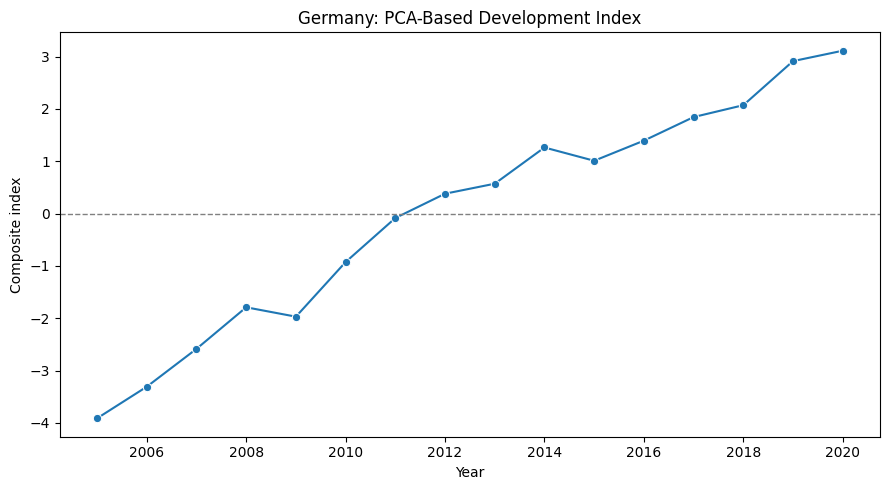

In [13]:
plt.figure(figsize=(9, 5))
sns.lineplot(data=result_df, x="Year", y="development_index", marker="o")
plt.axhline(y=0, color="gray", linestyle="--", linewidth=1)
plt.title(f"{country_name}: PCA-Based Development Index")
plt.ylabel("Composite index")
plt.tight_layout()
plt.savefig(MODULE_OUTPUT_DIR / "Homework5_development_index_line.png", bbox_inches="tight")
plt.show()


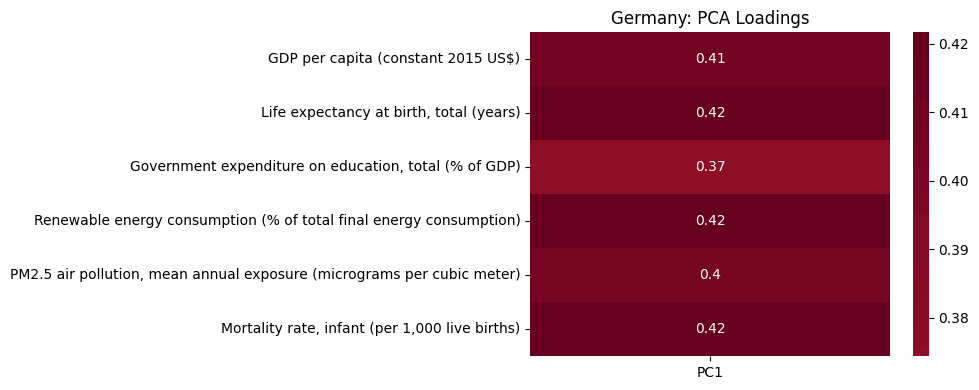

In [14]:
plt.figure(figsize=(10, 4))
sns.heatmap(loadings.iloc[:, :n_components], annot=True, cmap="RdBu_r", center=0)
plt.title(f"{country_name}: PCA Loadings")
plt.tight_layout()
plt.savefig(MODULE_OUTPUT_DIR / "Homework5_pca_loadings_heatmap.png", bbox_inches="tight")
plt.show()


## Interpretation notes for the report

One reasonable interpretation is:

- **PC1** behaves like a broad development factor: it loads positively on income, life expectancy, renewable energy, better air quality, and lower infant mortality.
- **PC2** mainly separates periods with relatively stronger public education spending from periods where other indicators improved more quickly.
- The final composite index rises over time, which is consistent with Germany's steady gains in income, health, cleaner air, and energy transition during 2005-2020.

For the report, you can also compare Germany with another country by discussing differences in raw indicators, even if the PCA itself is estimated for Germany only.


In [15]:
report_materials = pd.DataFrame(
    {
        "file": [
            "Homework5_selected_indicators.csv",
            "Homework5_kmo_bartlett.csv",
            "Homework5_pca_summary.csv",
            "Homework5_pca_loadings.csv",
            "Homework5_development_index.csv",
            "Homework5_scree_plot.png",
            "Homework5_development_index_line.png",
            "Homework5_pca_loadings_heatmap.png",
        ]
    }
)

report_materials


,file
0,Homework5_selected_indicators.csv
1,Homework5_kmo_bartlett.csv
2,Homework5_pca_summary.csv
3,Homework5_pca_loadings.csv
4,Homework5_development_index.csv
5,Homework5_scree_plot.png
6,Homework5_development_index_line.png
7,Homework5_pca_loadings_heatmap.png
